# M5 Assignment 1
Data Reduction Using PCA
Business Context:
The dataset represents the performance of multiple retail stores based on sales and growth metrics across five competing brands. The objective is to evaluate overall store performance and enable comparative analysis for ranking and strategic decision-making.

Dataset Description
* store_id – Unique identifier for each store
* Location – City in which the store is located
* Brand1_Sales – Annual Sales of Brand 1 recorded at the store
* Brand1_Growth – Growth rate of Brand 1 sales (%)
* Similar information available for Brand 2 To Brand 5

Tasks
1. Import the dataset and understand the structure of variables
1. Identify numerical variables and standardize them
1. Apply Principal Component Analysis (PCA) on scaled data
1. Examine explained variance and cumulative variance
1. Use scree plot to determine no of components
1. Display and interpret the PCA loading matrix
1. Compute principal component scores and rank stores using PC1

In [96]:
import pandas as pd

df = pd.read_csv("M5 ASSIGNMENT 1 DATA.csv")
df.head()

,store_id,Brand1_Sales,Brand1_Growth,Brand2_Sales,Brand2_Growth,Brand3_Sales,Brand3_Growth,Brand4_Sales,Brand4_Growth,Brand5_Sales,Brand5_Growth,Location
0,81,69.12,4.35,65.47,3.65,36.40,2.81,67.50,2.63,33.16,2.23,City4
1,303,22.13,2.10,26.53,1.78,17.83,1.63,26.12,1.52,18.74,1.20,City3
2,199,32.68,3.26,29.02,2.36,39.38,2.72,56.45,2.50,32.56,2.49,City5
3,99,65.71,3.81,68.64,3.36,24.55,1.97,48.94,1.94,28.10,2.25,City4
4,332,21.85,2.06,25.90,1.75,20.86,1.72,34.26,1.43,23.25,1.18,City3


In [97]:
df.dtypes

store_id           int64
Brand1_Sales     float64
Brand1_Growth    float64
Brand2_Sales     float64
Brand2_Growth    float64
Brand3_Sales     float64
Brand3_Growth    float64
Brand4_Sales     float64
Brand4_Growth    float64
Brand5_Sales     float64
Brand5_Growth    float64
Location          object
dtype: object

In [98]:
df.describe()

,store_id,Brand1_Sales,Brand1_Growth,Brand2_Sales,Brand2_Growth,Brand3_Sales,Brand3_Growth,Brand4_Sales,Brand4_Growth,Brand5_Sales,Brand5_Growth
count,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,207.987893,64.874867,4.381235,69.197409,3.606538,36.822446,3.221768,64.615642,3.182324,39.309806,2.944891
std,121.199236,54.056078,2.861460,58.929490,2.190150,19.899356,2.021169,37.977929,2.084124,23.272704,2.194744
min,0.000000,9.850000,1.140000,14.090000,1.000000,11.830000,0.930000,5.500000,0.870000,7.770000,0.660000
25%,103.000000,25.360000,2.200000,28.160000,1.870000,21.350000,1.720000,36.350000,1.560000,23.050000,1.430000
50%,209.000000,44.180000,3.500000,43.710000,2.960000,31.090000,2.520000,51.880000,2.490000,31.740000,2.240000
75%,312.000000,90.490000,5.820000,97.520000,4.770000,47.090000,4.110000,82.870000,4.250000,50.440000,3.520000
max,419.000000,420.000000,17.840000,422.000000,12.000000,117.070000,11.640000,240.000000,11.030000,175.000000,14.090000


In [99]:
df.isnull().sum()

store_id         0
Brand1_Sales     0
Brand1_Growth    0
Brand2_Sales     0
Brand2_Growth    0
Brand3_Sales     0
Brand3_Growth    0
Brand4_Sales     0
Brand4_Growth    0
Brand5_Sales     0
Brand5_Growth    0
Location         0
dtype: int64

## Variable Exploration and Business Relevance

Before applying PCA, it is important to identify which variables should enter the analysis and what each of them represents in the business context.

- `store_id` is only a store identifier, so it should not be used as a PCA input.
- `Location` is a categorical descriptor that may be useful later for interpretation, but it is not directly used in standard PCA.
- The ten sales and growth variables are the core quantitative measures of store performance.

From a business perspective, sales variables capture the current scale of a store's performance, while growth variables capture momentum. A store performing well across both dimensions can be considered competitively stronger. PCA is useful here because these metrics are likely to overlap and reflect a broader underlying concept: overall store performance.

In [100]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
pca_features = [col for col in numeric_cols if col != "store_id"]

print("Numeric columns:", numeric_cols)
print("\nVariables selected for PCA:", pca_features)

Numeric columns: ['store_id', 'Brand1_Sales', 'Brand1_Growth', 'Brand2_Sales', 'Brand2_Growth', 'Brand3_Sales', 'Brand3_Growth', 'Brand4_Sales', 'Brand4_Growth', 'Brand5_Sales', 'Brand5_Growth']

Variables selected for PCA: ['Brand1_Sales', 'Brand1_Growth', 'Brand2_Sales', 'Brand2_Growth', 'Brand3_Sales', 'Brand3_Growth', 'Brand4_Sales', 'Brand4_Growth', 'Brand5_Sales', 'Brand5_Growth']


The PCA model will therefore focus on the ten continuous performance variables: sales and growth for Brand 1 through Brand 5. This keeps the analysis centered on business performance rather than identification fields.

In [101]:
feature_summary = pd.DataFrame({
    "Variable": pca_features,
    "Mean": df[pca_features].mean().round(2).values,
    "Std_Dev": df[pca_features].std().round(2).values,
    "Min": df[pca_features].min().round(2).values,
    "Max": df[pca_features].max().round(2).values
})

feature_summary

,Variable,Mean,Std_Dev,Min,Max
0,Brand1_Sales,64.87,54.06,9.85,420.00
1,Brand1_Growth,4.38,2.86,1.14,17.84
2,Brand2_Sales,69.20,58.93,14.09,422.00
3,Brand2_Growth,3.61,2.19,1.00,12.00
4,Brand3_Sales,36.82,19.90,11.83,117.07
5,Brand3_Growth,3.22,2.02,0.93,11.64
6,Brand4_Sales,64.62,37.98,5.50,240.00
7,Brand4_Growth,3.18,2.08,0.87,11.03
8,Brand5_Sales,39.31,23.27,7.77,175.00
9,Brand5_Growth,2.94,2.19,0.66,14.09


The summary table shows that the variables are measured on different scales. Sales figures have much larger magnitudes than growth rates, so standardization will be necessary before PCA. Without scaling, the resulting components would be driven more by unit size than by actual business importance.

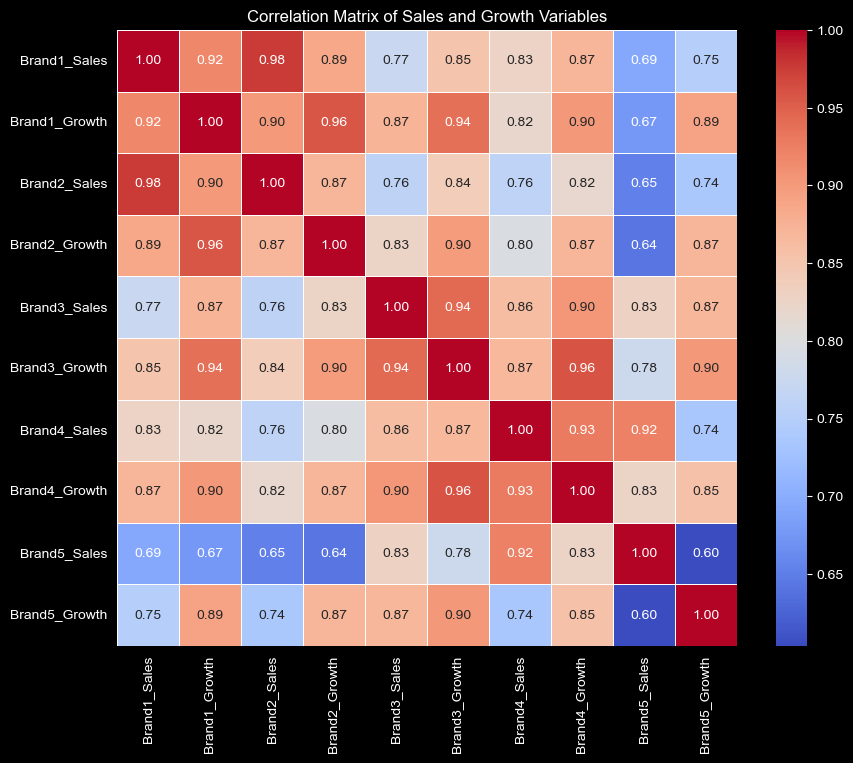

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df[pca_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Sales and Growth Variables")
plt.show()

The correlation matrix helps assess whether the variables carry overlapping information. This is an essential step before PCA because dimension reduction is most useful when many variables are strongly related.

In this dataset, strong stores are expected to perform well across several brands, which means sales and growth measures should move together. If that happens, the ten original variables may be reflecting a common latent structure rather than ten independent dimensions.

In [103]:
avg_abs_corr = corr_matrix.where(~corr_matrix.eq(1)).abs().stack().mean()

high_corr_pairs = corr_matrix.where(~corr_matrix.eq(1)).stack().reset_index()
high_corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Variable_1"] < high_corr_pairs["Variable_2"]]
high_corr_pairs = high_corr_pairs.reindex(high_corr_pairs["Correlation"].abs().sort_values(ascending=False).index)

print("Average absolute correlation:", round(avg_abs_corr, 3))
high_corr_pairs.head(10)

Average absolute correlation: 0.836


,Variable_1,Variable_2,Correlation
1,Brand1_Sales,Brand2_Sales,0.976302
51,Brand3_Growth,Brand4_Growth,0.959316
11,Brand1_Growth,Brand2_Growth,0.957503
49,Brand3_Growth,Brand3_Sales,0.943860
13,Brand1_Growth,Brand3_Growth,0.936673
69,Brand4_Growth,Brand4_Sales,0.928755
61,Brand4_Sales,Brand5_Sales,0.922619
9,Brand1_Growth,Brand1_Sales,0.916465
42,Brand3_Sales,Brand4_Growth,0.903487
53,Brand3_Growth,Brand5_Growth,0.901419


A high average absolute correlation would confirm that the variables contain substantial redundancy. In business terms, that would mean the dataset is observing the same performance pattern from multiple angles.

## Standardize the Variables

PCA is based on variance, so all input variables must be placed on the same scale before the model is fitted. This matters here because sales variables have much larger numerical magnitudes than growth variables.

Standardization transforms each variable to have mean 0 and standard deviation 1. As a result, the components reflect the relationships among variables rather than differences in units of measurement.

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pca_features])
X_scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

X_scaled_df.describe().round(2)

,Brand1_Sales,Brand1_Growth,Brand2_Sales,Brand2_Growth,Brand3_Sales,Brand3_Growth,Brand4_Sales,Brand4_Growth,Brand5_Sales,Brand5_Growth
count,413.00,413.00,413.00,413.00,413.00,413.00,413.00,413.00,413.00,413.00
mean,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.02,-1.13,-0.94,-1.19,-1.26,-1.14,-1.56,-1.11,-1.36,-1.04
25%,-0.73,-0.76,-0.70,-0.79,-0.78,-0.74,-0.75,-0.78,-0.70,-0.69
50%,-0.38,-0.31,-0.43,-0.30,-0.29,-0.35,-0.34,-0.33,-0.33,-0.32
75%,0.47,0.50,0.48,0.53,0.52,0.44,0.48,0.51,0.48,0.26
max,6.58,4.71,5.99,3.84,4.04,4.17,4.62,3.77,5.84,5.08


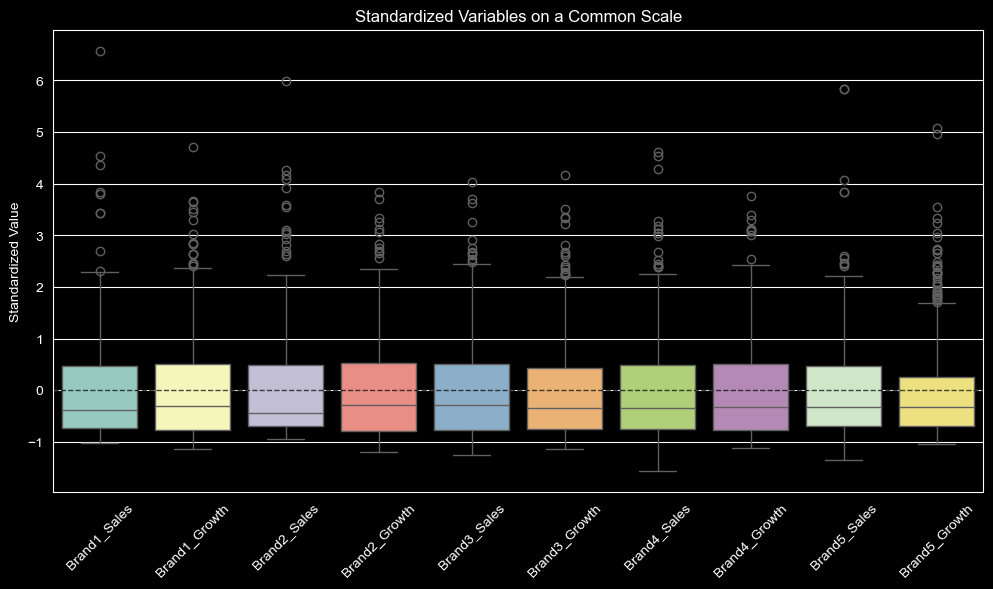

In [105]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_scaled_df)
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.title("Standardized Variables on a Common Scale")
plt.xticks(rotation=45)
plt.ylabel("Standardized Value")
plt.show()

The boxplot confirms that the standardized variables are centered around zero and expressed on a comparable scale. This visual check supports the summary statistics and shows that no variable is dominating the PCA merely because of its original measurement units.

## Apply PCA

The PCA model extracts new variables called principal components. Each component is a linear combination of the original variables, and the components are ordered by how much variance they explain.

In [106]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled_df)

PCA()

## Explained Variance and Cumulative Variance

The explained variance ratio shows how much of the total variability is captured by each principal component. The cumulative variance shows how much information is retained as components are added one by one.

In [107]:
explained_variance_df = pd.DataFrame({
    "Principal_Component": [f"PC{i}" for i in range(1, len(pca_features) + 1)],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative_Variance": pca.explained_variance_ratio_.cumsum()
})

explained_variance_df.round(4)

,Principal_Component,Explained_Variance_Ratio,Cumulative_Variance
0,PC1,0.8543,0.8543
1,PC2,0.0655,0.9198
2,PC3,0.0426,0.9624
3,PC4,0.0124,0.9748
4,PC5,0.0090,0.9838
5,PC6,0.0071,0.9909
6,PC7,0.0036,0.9945
7,PC8,0.0028,0.9974
8,PC9,0.0019,0.9993
9,PC10,0.0007,1.0000


The first principal component explains more than 80% of the total variance. This conclusion comes directly from the `Explained_Variance_Ratio` of `PC1`.

If the value for `PC1` is approximately `0.8543`, this means that `PC1` alone captures `85.43%` of the total variance in the standardized dataset. In practical terms, a very large share of the information contained in the ten original variables is concentrated in a single dominant dimension.

This is exactly what we expect when many variables are strongly correlated: they carry overlapping information, and PCA compresses that shared structure into the first component.

## Scree Plot

The scree plot helps determine how many components should be retained. A steep drop after the first component indicates that most of the useful information is already captured by `PC1`.

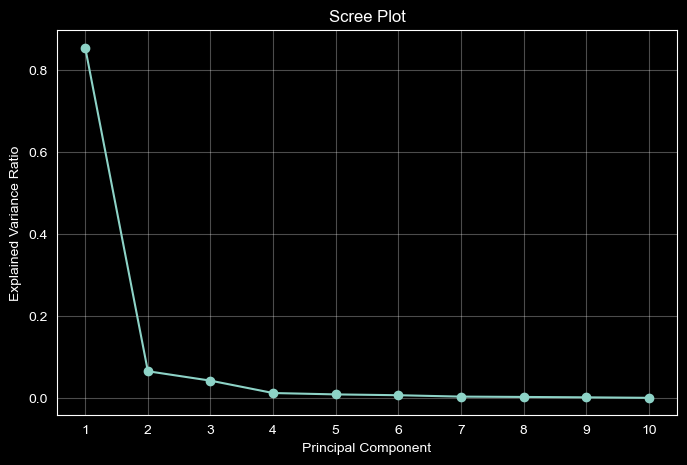

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_features) + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(pca_features) + 1))
plt.grid(alpha=0.3)
plt.show()

If the scree plot shows a sharp elbow after the first component, then retaining one main component is statistically reasonable for summarizing overall store performance.

## PCA Loading Matrix

The loading matrix shows the contribution of each original variable to each principal component. Variables with larger absolute loadings are more influential in defining that component.

In [109]:
loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(1, len(pca_features) + 1)],
    index=pca_features
)

loading_matrix.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Brand1_Sales,0.3168,-0.2280,-0.4758,0.0276,-0.2055,0.1447,0.1927,-0.1508,-0.3207,0.6282
Brand1_Growth,0.3292,-0.2638,0.0419,-0.0624,0.2049,-0.1703,0.4511,0.6867,-0.1858,-0.1895
Brand2_Sales,0.3083,-0.3084,-0.4794,0.4051,-0.0640,0.1521,-0.2126,-0.0538,0.3156,-0.4909
Brand2_Growth,0.3198,-0.3030,0.0445,-0.4142,0.6233,-0.1629,-0.3404,-0.3147,-0.0387,0.0312
Brand3_Sales,0.3200,0.1933,0.3230,0.5609,0.2074,-0.1790,0.3803,-0.4514,-0.1237,-0.0503
Brand3_Growth,0.3328,0.0040,0.2189,0.1496,-0.2362,-0.4641,-0.2878,0.2333,0.4875,0.4157
Brand4_Sales,0.3151,0.3907,-0.1557,-0.4669,-0.0321,0.1599,0.4328,-0.1481,0.5151,-0.0672
Brand4_Growth,0.3310,0.1294,0.0629,-0.2890,-0.5614,-0.2980,-0.1752,-0.1513,-0.4315,-0.3775
Brand5_Sales,0.2812,0.6632,-0.1832,0.1432,0.2802,0.2207,-0.3744,0.3142,-0.2384,0.0633
Brand5_Growth,0.3049,-0.2117,0.5710,-0.0243,-0.1723,0.6999,-0.1121,0.0463,0.0089,0.0355


In [110]:
loading_matrix["PC1"].sort_values(key=lambda s: s.abs(), ascending=False).round(4)

Brand3_Growth    0.3328
Brand4_Growth    0.3310
Brand1_Growth    0.3292
Brand3_Sales     0.3200
Brand2_Growth    0.3198
Brand1_Sales     0.3168
Brand4_Sales     0.3151
Brand2_Sales     0.3083
Brand5_Growth    0.3049
Brand5_Sales     0.2812
Name: PC1, dtype: float64

If the `PC1` loadings are all positive and relatively strong across both sales and growth variables, then `PC1` can be interpreted as a general store-performance index. Stores with high `PC1` scores tend to perform well across multiple brands and across both current sales and growth momentum.

## Principal Component Scores and Store Ranking

Once the PCA model is fitted, component scores can be computed for each store. These scores place each store on the new reduced dimensions created by PCA.

In [111]:
pca_scores = pd.DataFrame(
    pca.transform(X_scaled_df),
    columns=[f"PC{i}" for i in range(1, len(pca_features) + 1)]
)

store_scores = pd.concat([df[["store_id", "Location"]], pca_scores], axis=1)
store_scores.head()

,store_id,Location,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,81,City4,-0.304221,-0.117486,-0.224420,-0.062249,0.170395,-0.096565,0.282570,-0.129546,0.073087,0.066200
1,303,City3,-2.647819,-0.238445,-0.012217,0.023405,-0.116722,-0.092511,-0.089628,0.076605,-0.034722,-0.010568
2,199,City5,-1.073521,0.371379,0.503930,0.161193,-0.038611,-0.084188,0.263891,-0.098916,0.031636,0.019724
3,99,City4,-1.063774,-0.526990,-0.417224,-0.079281,0.172441,0.235018,0.038606,0.015746,-0.035570,0.033330
4,332,City3,-2.493060,0.012406,-0.023712,0.057955,-0.031982,-0.054625,-0.016015,0.049550,0.052434,0.018372


In [112]:
store_ranking = store_scores.sort_values("PC1", ascending=False).reset_index(drop=True)
store_ranking[["store_id", "Location", "PC1"]].head(10)

,store_id,Location,PC1
0,58,City4,13.559766
1,38,City4,9.707085
2,56,City4,9.685600
3,39,City4,9.577144
4,117,City6,9.315143
5,60,City4,9.220595
6,202,City5,9.191353
7,201,City5,7.723856
8,116,City6,7.634408
9,57,City4,7.590034


Ranking stores by `PC1` is appropriate because `PC1` explains the largest share of total variance and appears to summarize overall store strength. A higher `PC1` score indicates better combined performance across the sales and growth variables.

The PCA results show that the ten original business metrics can be reduced very effectively into a smaller number of dimensions, especially `PC1`. Because the first component explains most of the total variance, it acts as a compact and statistically grounded performance index.

From a managerial perspective, this means that overall store performance across multiple brands is largely driven by a shared underlying factor. Therefore, using `PC1` to rank stores provides a practical way to compare performance while avoiding the complexity of evaluating ten separate indicators individually.